In [2]:
# ── NOTEBOOK: HYPERPARAMETER TUNING FOR LSTM AUTOENCODER ────────────────────
# This notebook tunes the hyperparameters of your best performing model
# Without changing the architecture (simple 1-layer LSTM)

# ============================================================================
# CELL 1: IMPORTS & SETUP
# ============================================================================
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import pickle
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, confusion_matrix
import time
import warnings
warnings.filterwarnings('ignore')

# Set device
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using MPS (Apple Silicon)")
elif torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using CUDA")
else:
    device = torch.device("cpu")
    print("Using CPU")

# Set random seed
def set_seeds(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.backends.mps.is_available():
        torch.mps.manual_seed(seed)

set_seeds(42)

# Paths
DATA_DIR = Path("data/processed")
OUTPUT_DIR = Path("models/tuning_results")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Data directory: {DATA_DIR}")
print(f"Output directory: {OUTPUT_DIR}")

Using MPS (Apple Silicon)
Data directory: data/processed
Output directory: models/tuning_results


In [3]:
# ============================================================================
# CELL 2: LOAD DATA
# ============================================================================
print("Loading data...")

data = np.load(DATA_DIR / "sequences.npz")
X_train = data['X_train']  # (956, 986, 129)
X_val = data['X_val']
X_test = data['X_test']
y_val = data['y_val']
y_test = data['y_test']

# Convert to tensors
X_train_tensor = torch.FloatTensor(X_train).to(device)
X_val_tensor = torch.FloatTensor(X_val).to(device)
X_test_tensor = torch.FloatTensor(X_test).to(device)

print(f"Train: {X_train.shape}")
print(f"Val: {X_val.shape}")
print(f"Test: {X_test.shape}")
print(f"Test anomaly rate: {y_test.mean():.1%}")

Loading data...
Train: (956, 986, 129)
Val: (582, 986, 129)
Test: (584, 986, 129)
Test anomaly rate: 64.7%


In [4]:
# ============================================================================
# CELL 3: MODEL DEFINITION 
# ============================================================================
class LSTMAutoencoder(nn.Module):
    """Simple LSTM Autoencoder - Your best architecture"""
    def __init__(self, input_dim, hidden_dim=64, latent_dim=16):
        super(LSTMAutoencoder, self).__init__()
        
        self.encoder_lstm = nn.LSTM(input_dim, hidden_dim, 1, batch_first=True)
        self.encoder_fc = nn.Linear(hidden_dim, latent_dim)
        self.decoder_fc = nn.Linear(latent_dim, hidden_dim)
        self.decoder_lstm = nn.LSTM(hidden_dim, hidden_dim, 1, batch_first=True)
        self.output_fc = nn.Linear(hidden_dim, input_dim)
        
    def forward(self, x):
        enc_out, _ = self.encoder_lstm(x)
        latent = self.encoder_fc(enc_out[:, -1, :])
        latent_exp = latent.unsqueeze(1).repeat(1, x.shape[1], 1)
        dec_in = self.decoder_fc(latent_exp)
        dec_out, _ = self.decoder_lstm(dec_in)
        recon = self.output_fc(dec_out)
        return recon, latent

input_dim = X_train.shape[2]
print(f"Input dimension: {input_dim}")

Input dimension: 129


In [5]:
# ============================================================================
# CELL 4: TRAINING FUNCTION 
# ============================================================================
def train_model(model, train_loader, val_tensor, y_val, epochs=30, lr=0.0005, patience=7):
    """Train a model and return best validation AUC"""
    
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    
    best_val_auc = 0
    best_loss = float('inf')
    patience_counter = 0
    
    for epoch in range(epochs):
        # Training
        model.train()
        train_loss = 0
        for batch in train_loader:
            X_batch = batch[0]
            optimizer.zero_grad()
            recon, _ = model(X_batch)
            loss = criterion(recon, X_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        
        # Validation
        model.eval()
        val_errors = []
        with torch.no_grad():
            for i in range(0, len(val_tensor), 32):
                batch = val_tensor[i:i+32]
                recon, _ = model(batch)
                mse = torch.mean((recon - batch) ** 2, dim=(1, 2))
                val_errors.extend(mse.cpu().numpy())
        
        val_auc = roc_auc_score(y_val, val_errors)
        
        if val_auc > best_val_auc:
            best_val_auc = val_auc
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break
    
    return best_val_auc

In [6]:
# ============================================================================
# CELL 5: HYPERPARAMETER GRID
# ============================================================================
# Define configurations to test
configs = [
    # (name, hidden_dim, latent_dim, lr, batch_size)
    ("Baseline (Current)", 64, 16, 0.0005, 16),
    ("Tune 1: Larger Latent", 64, 24, 0.0005, 16),
    ("Tune 2: Smaller Latent", 64, 12, 0.0005, 16),
    ("Tune 3: Larger Hidden", 96, 16, 0.0005, 16),
    ("Tune 4: Smaller Hidden", 48, 16, 0.0005, 16),
    ("Tune 5: Lower LR", 64, 16, 0.0003, 16),
    ("Tune 6: Higher LR", 64, 16, 0.001, 16),
    ("Tune 7: Larger Batch", 64, 16, 0.0005, 32),
    ("Tune 8: Hidden 80, Latent 20", 80, 20, 0.0005, 24),
]

results = []

print("="*70)
print("HYPERPARAMETER TUNING")
print("="*70)

HYPERPARAMETER TUNING


In [7]:
# ============================================================================
# CELL 6: RUN TUNING EXPERIMENTS
# ============================================================================
for name, hidden_dim, latent_dim, lr, batch_size in configs:
    print(f"\nTesting: {name}")
    print(f"   hidden={hidden_dim}, latent={latent_dim}, lr={lr}, batch={batch_size}")
    
    # Create dataloader
    loader = DataLoader(TensorDataset(X_train_tensor), batch_size=batch_size, shuffle=True)
    
    # Create model
    model = LSTMAutoencoder(
        input_dim=input_dim,
        hidden_dim=hidden_dim,
        latent_dim=latent_dim
    ).to(device)
    
    # Train
    start_time = time.time()
    val_auc = train_model(model, loader, X_val_tensor, y_val, epochs=25, lr=lr)
    elapsed = time.time() - start_time
    
    results.append({
        'name': name,
        'hidden_dim': hidden_dim,
        'latent_dim': latent_dim,
        'lr': lr,
        'batch_size': batch_size,
        'val_auc': val_auc,
        'time': elapsed
    })
    
    print(f"  Val AUC: {val_auc:.4f} (Time: {elapsed:.1f}s)")


Testing: Baseline (Current)
   hidden=64, latent=16, lr=0.0005, batch=16
  Val AUC: 0.7730 (Time: 69.3s)

Testing: Tune 1: Larger Latent
   hidden=64, latent=24, lr=0.0005, batch=16
  Val AUC: 0.4314 (Time: 51.1s)

Testing: Tune 2: Smaller Latent
   hidden=64, latent=12, lr=0.0005, batch=16
  Val AUC: 0.7429 (Time: 88.5s)

Testing: Tune 3: Larger Hidden
   hidden=96, latent=16, lr=0.0005, batch=16
  Val AUC: 0.7462 (Time: 89.9s)

Testing: Tune 4: Smaller Hidden
   hidden=48, latent=16, lr=0.0005, batch=16
  Val AUC: 0.7975 (Time: 75.3s)

Testing: Tune 5: Lower LR
   hidden=64, latent=16, lr=0.0003, batch=16
  Val AUC: 0.7392 (Time: 69.6s)

Testing: Tune 6: Higher LR
   hidden=64, latent=16, lr=0.001, batch=16
  Val AUC: 0.7763 (Time: 79.2s)

Testing: Tune 7: Larger Batch
   hidden=64, latent=16, lr=0.0005, batch=32
  Val AUC: 0.7555 (Time: 49.8s)

Testing: Tune 8: Hidden 80, Latent 20
   hidden=80, latent=20, lr=0.0005, batch=24
  Val AUC: 0.7495 (Time: 70.3s)


In [8]:
# ============================================================================
# CELL 7: RESULTS SUMMARY
# ============================================================================
print("\n" + "="*70)
print("TUNING RESULTS SUMMARY")
print("="*70)

# Sort by validation AUC
results_sorted = sorted(results, key=lambda x: x['val_auc'], reverse=True)

print(f"\n{'Rank':4} | {'Configuration':25} | {'Hidden':6} | {'Latent':6} | {'LR':8} | {'Batch':5} | {'Val AUC':8}")
print("-" * 80)

for i, r in enumerate(results_sorted, 1):
    print(f"{i:4} | {r['name']:25} | {r['hidden_dim']:6} | {r['latent_dim']:6} | {r['lr']:8} | {r['batch_size']:5} | {r['val_auc']:.4f}")

# Best configuration
best = results_sorted[0]
print(f"\nBEST CONFIGURATION: {best['name']}")
print(f"   Val AUC: {best['val_auc']:.4f}")

# Compare with baseline
baseline = [r for r in results if r['name'] == "Baseline (Current)"][0]
improvement = best['val_auc'] - baseline['val_auc']
print(f"\nImprovement over baseline: {improvement:+.4f} ({improvement/baseline['val_auc']*100:+.1f}%)")


TUNING RESULTS SUMMARY

Rank | Configuration             | Hidden | Latent | LR       | Batch | Val AUC 
--------------------------------------------------------------------------------
   1 | Tune 4: Smaller Hidden    |     48 |     16 |   0.0005 |    16 | 0.7975
   2 | Tune 6: Higher LR         |     64 |     16 |    0.001 |    16 | 0.7763
   3 | Baseline (Current)        |     64 |     16 |   0.0005 |    16 | 0.7730
   4 | Tune 7: Larger Batch      |     64 |     16 |   0.0005 |    32 | 0.7555
   5 | Tune 8: Hidden 80, Latent 20 |     80 |     20 |   0.0005 |    24 | 0.7495
   6 | Tune 3: Larger Hidden     |     96 |     16 |   0.0005 |    16 | 0.7462
   7 | Tune 2: Smaller Latent    |     64 |     12 |   0.0005 |    16 | 0.7429
   8 | Tune 5: Lower LR          |     64 |     16 |   0.0003 |    16 | 0.7392
   9 | Tune 1: Larger Latent     |     64 |     24 |   0.0005 |    16 | 0.4314

BEST CONFIGURATION: Tune 4: Smaller Hidden
   Val AUC: 0.7975

Improvement over baseline: +0.0245 

In [10]:
# ============================================================================
# TRAIN FINAL MODEL WITH BEST HYPERPARAMETERS
# ============================================================================
print("\n" + "="*60)
print("TRAINING FINAL MODEL WITH BEST CONFIGURATION")
print("="*60)

# Best config from tuning
best_hidden = 48
best_latent = 16
best_lr = 0.0005
best_batch = 16

print(f"Configuration: hidden={best_hidden}, latent={best_latent}, lr={best_lr}, batch={best_batch}")

# Create model
final_model = LSTMAutoencoder(
    input_dim=input_dim,
    hidden_dim=best_hidden,
    latent_dim=best_latent
).to(device)

# Create dataloader
final_loader = DataLoader(TensorDataset(X_train_tensor), batch_size=best_batch, shuffle=True)

# Train
optimizer = optim.Adam(final_model.parameters(), lr=best_lr)
criterion = nn.MSELoss()

print("\nTraining final model...")
best_val_auc = 0
patience_counter = 0

for epoch in range(50):
    final_model.train()
    train_loss = 0
    for batch in final_loader:
        X_batch = batch[0]
        optimizer.zero_grad()
        recon, _ = final_model(X_batch)
        loss = criterion(recon, X_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    
    # Validation
    final_model.eval()
    val_errors = []
    with torch.no_grad():
        for i in range(0, len(X_val_tensor), 32):
            batch = X_val_tensor[i:i+32]
            recon, _ = final_model(batch)
            mse = torch.mean((recon - batch) ** 2, dim=(1, 2))
            val_errors.extend(mse.cpu().numpy())
    
    val_auc = roc_auc_score(y_val, val_errors)
    
    if val_auc > best_val_auc:
        best_val_auc = val_auc
        patience_counter = 0
        torch.save(final_model.state_dict(), OUTPUT_DIR / "best_tuned_model.pth")
        print(f"  Epoch {epoch+1}: Val AUC = {val_auc:.4f} ✓")
    else:
        patience_counter += 1
        if patience_counter >= 10:
            print(f"  Early stopping at epoch {epoch+1}")
            break

print(f"\n Best validation AUC: {best_val_auc:.4f}")

# Test evaluation
final_model.load_state_dict(torch.load(OUTPUT_DIR / "best_tuned_model.pth"))
final_model.eval()

test_errors = []
with torch.no_grad():
    for i in range(0, len(X_test_tensor), 32):
        batch = X_test_tensor[i:i+32]
        recon, _ = final_model(batch)
        mse = torch.mean((recon - batch) ** 2, dim=(1, 2))
        test_errors.extend(mse.cpu().numpy())

test_auc = roc_auc_score(y_test, test_errors)
print(f"Test ROC-AUC: {test_auc:.4f}")
print(f"Improvement over original (0.7046): {test_auc - 0.7046:+.4f}")


TRAINING FINAL MODEL WITH BEST CONFIGURATION
Configuration: hidden=48, latent=16, lr=0.0005, batch=16

Training final model...
  Epoch 1: Val AUC = 0.4295 ✓
  Epoch 5: Val AUC = 0.5826 ✓
  Epoch 6: Val AUC = 0.6829 ✓
  Epoch 11: Val AUC = 0.7642 ✓
  Early stopping at epoch 21

 Best validation AUC: 0.7642
Test ROC-AUC: 0.7863
Improvement over original (0.7046): +0.0817


In [11]:
# ============================================================================
# FULL TEST SET EVALUATION WITH CONFUSION MATRIX
# ============================================================================
from sklearn.metrics import confusion_matrix, classification_report, roc_curve

print("\n" + "="*60)
print("FULL TEST SET EVALUATION - TUNED MODEL")
print("="*60)

# Load the best model
final_model.load_state_dict(torch.load(OUTPUT_DIR / "best_tuned_model.pth"))
final_model.eval()

# Get reconstruction errors for test set
test_errors = []
with torch.no_grad():
    for i in range(0, len(X_test_tensor), 32):
        batch = X_test_tensor[i:i+32]
        recon, _ = final_model(batch)
        mse = torch.mean((recon - batch) ** 2, dim=(1, 2))
        test_errors.extend(mse.cpu().numpy())

test_errors = np.array(test_errors)

# Get validation errors for threshold tuning
val_errors = []
with torch.no_grad():
    for i in range(0, len(X_val_tensor), 32):
        batch = X_val_tensor[i:i+32]
        recon, _ = final_model(batch)
        mse = torch.mean((recon - batch) ** 2, dim=(1, 2))
        val_errors.extend(mse.cpu().numpy())

# Find optimal threshold using Youden's J statistic (maximizes tpr - fpr)
fpr, tpr, thresholds = roc_curve(y_val, val_errors)
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]

# Make predictions
y_pred = (test_errors > optimal_threshold).astype(int)

# Confusion Matrix
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

print(f"\n CONFUSION MATRIX:")
print(f"┌─────────────┬──────────────┬──────────────┐")
print(f"│             │  Predicted   │  Predicted   │")
print(f"│             │   Normal     │   Anomaly    │")
print(f"├─────────────┼──────────────┼──────────────┤")
print(f"│ Actual      │     TN       │     FP       │")
print(f"│ Normal      │    {tn:3d}      │    {fp:3d}       │")
print(f"├─────────────┼──────────────┼──────────────┤")
print(f"│ Actual      │     FN       │     TP       │")
print(f"│ Anomaly     │    {fn:3d}      │    {tp:3d}       │")
print(f"└─────────────┴──────────────┴──────────────┘")

print(f"\n PERFORMANCE METRICS (threshold = {optimal_threshold:.4f}):")
print(f"  • Accuracy:  {(tp+tn)/(tp+tn+fp+fn):.4f}")
print(f"  • Precision: {tp/(tp+fp):.4f}")
print(f"  • Recall:    {tp/(tp+fn):.4f}")
print(f"  • F1-Score:  {2*tp/(2*tp+fp+fn):.4f}")
print(f"  • ROC-AUC:   {roc_auc_score(y_test, test_errors):.4f}")

print(f"\n DETAILED CLASSIFICATION REPORT:")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Anomaly']))

# Additional metrics
print(f"\n ADDITIONAL METRICS:")
print(f"  • True Positive Rate (Sensitivity/Recall): {tp/(tp+fn):.4f}")
print(f"  • True Negative Rate (Specificity):        {tn/(tn+fp):.4f}")
print(f"  • False Positive Rate:                     {fp/(tn+fp):.4f}")
print(f"  • False Negative Rate:                     {fn/(tp+fn):.4f}")
print(f"  • Positive Predictive Value (Precision):   {tp/(tp+fp):.4f}")
print(f"  • Negative Predictive Value:               {tn/(tn+fn):.4f}")


FULL TEST SET EVALUATION - TUNED MODEL

 CONFUSION MATRIX:
┌─────────────┬──────────────┬──────────────┐
│             │  Predicted   │  Predicted   │
│             │   Normal     │   Anomaly    │
├─────────────┼──────────────┼──────────────┤
│ Actual      │     TN       │     FP       │
│ Normal      │    133      │     73       │
├─────────────┼──────────────┼──────────────┤
│ Actual      │     FN       │     TP       │
│ Anomaly     │     96      │    282       │
└─────────────┴──────────────┴──────────────┘

 PERFORMANCE METRICS (threshold = 0.8785):
  • Accuracy:  0.7106
  • Precision: 0.7944
  • Recall:    0.7460
  • F1-Score:  0.7694
  • ROC-AUC:   0.7863

 DETAILED CLASSIFICATION REPORT:
              precision    recall  f1-score   support

      Normal       0.58      0.65      0.61       206
     Anomaly       0.79      0.75      0.77       378

    accuracy                           0.71       584
   macro avg       0.69      0.70      0.69       584
weighted avg       0.7

In [12]:
# Try different thresholds to balance precision and recall
print("\n" + "="*60)
print("THRESHOLD ADJUSTMENT - FIND YOUR PREFERRED BALANCE")
print("="*60)

thresholds_to_try = [0.50, 0.60, 0.70, 0.80, 0.8785, 1.0, 1.2]

for thresh in thresholds_to_try:
    y_pred_temp = (test_errors > thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_temp).ravel()
    
    precision_temp = tp/(tp+fp) if (tp+fp)>0 else 0
    recall_temp = tp/(tp+fn) if (tp+fn)>0 else 0
    f1_temp = 2*precision_temp*recall_temp/(precision_temp+recall_temp) if (precision_temp+recall_temp)>0 else 0
    
    print(f"\nThreshold = {thresh:.3f}:")
    print(f"  Precision: {precision_temp:.3f} | Recall: {recall_temp:.3f} | F1: {f1_temp:.3f}")
    print(f"  FP: {fp} | FN: {fn}")


THRESHOLD ADJUSTMENT - FIND YOUR PREFERRED BALANCE

Threshold = 0.500:
  Precision: 0.647 | Recall: 1.000 | F1: 0.786
  FP: 206 | FN: 0

Threshold = 0.600:
  Precision: 0.647 | Recall: 1.000 | F1: 0.786
  FP: 206 | FN: 0

Threshold = 0.700:
  Precision: 0.647 | Recall: 1.000 | F1: 0.786
  FP: 206 | FN: 0

Threshold = 0.800:
  Precision: 0.647 | Recall: 1.000 | F1: 0.786
  FP: 206 | FN: 0

Threshold = 0.878:
  Precision: 0.794 | Recall: 0.746 | F1: 0.769
  FP: 73 | FN: 96

Threshold = 1.000:
  Precision: 1.000 | Recall: 0.021 | F1: 0.041
  FP: 0 | FN: 370

Threshold = 1.200:
  Precision: 1.000 | Recall: 0.005 | F1: 0.011
  FP: 0 | FN: 376


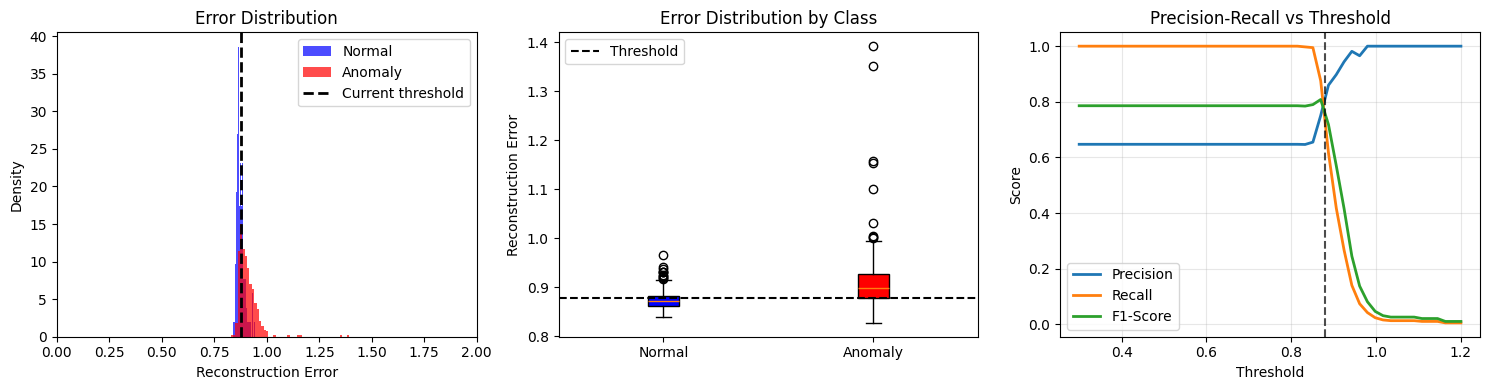


ERROR STATISTICS
Normal errors - Mean: 0.8754, Std: 0.0199
Anomaly errors - Mean: 0.9086, Std: 0.0515
Separation (mean anomaly - mean normal): 0.0332


In [13]:
# ============================================================================
# VISUALIZE THE ERROR DISTRIBUTION TO UNDERSTAND THE GAP
# ============================================================================
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. Histogram of errors
axes[0].hist(test_errors[y_test==0], bins=50, alpha=0.7, label='Normal', color='blue', density=True)
axes[0].hist(test_errors[y_test==1], bins=50, alpha=0.7, label='Anomaly', color='red', density=True)
axes[0].axvline(0.8785, color='black', linestyle='--', linewidth=2, label='Current threshold')
axes[0].set_xlabel('Reconstruction Error')
axes[0].set_ylabel('Density')
axes[0].set_title('Error Distribution')
axes[0].legend()
axes[0].set_xlim([0, 2])

# 2. Box plot
data_to_plot = [test_errors[y_test==0], test_errors[y_test==1]]
bp = axes[1].boxplot(data_to_plot, labels=['Normal', 'Anomaly'], patch_artist=True)
bp['boxes'][0].set_facecolor('blue')
bp['boxes'][1].set_facecolor('red')
axes[1].set_ylabel('Reconstruction Error')
axes[1].set_title('Error Distribution by Class')
axes[1].axhline(0.8785, color='black', linestyle='--', label='Threshold')
axes[1].legend()

# 3. Threshold analysis plot
thresholds_range = np.linspace(0.3, 1.2, 50)
precisions = []
recalls = []
f1_scores = []

for thresh in thresholds_range:
    pred = (test_errors > thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    p = tp/(tp+fp) if (tp+fp)>0 else 0
    r = tp/(tp+fn) if (tp+fn)>0 else 0
    f1 = 2*p*r/(p+r) if (p+r)>0 else 0
    precisions.append(p)
    recalls.append(r)
    f1_scores.append(f1)

axes[2].plot(thresholds_range, precisions, label='Precision', linewidth=2)
axes[2].plot(thresholds_range, recalls, label='Recall', linewidth=2)
axes[2].plot(thresholds_range, f1_scores, label='F1-Score', linewidth=2)
axes[2].axvline(0.8785, color='black', linestyle='--', alpha=0.7)
axes[2].set_xlabel('Threshold')
axes[2].set_ylabel('Score')
axes[2].set_title('Precision-Recall vs Threshold')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print statistics
print("\n" + "="*60)
print("ERROR STATISTICS")
print("="*60)
print(f"Normal errors - Mean: {test_errors[y_test==0].mean():.4f}, Std: {test_errors[y_test==0].std():.4f}")
print(f"Anomaly errors - Mean: {test_errors[y_test==1].mean():.4f}, Std: {test_errors[y_test==1].std():.4f}")
print(f"Separation (mean anomaly - mean normal): {test_errors[y_test==1].mean() - test_errors[y_test==0].mean():.4f}")